In [63]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [64]:
main_df = pd.read_csv("/Users/utkuseyithanoglu/Desktop/1999 czech banking/fraud_detection/utku_project/final_loan_data.csv")

In [65]:
main_df

,loan_id,account_id,amount,duration,payments,status,frequency,disp_id,client_id,birth_number,district_id,total_trans,total_trans_amount
0,4959,2,80952,24,3373.0,A,POPLATEK MESICNE,2,2,450204,1,478,3151479.3
1,4959,2,80952,24,3373.0,A,POPLATEK MESICNE,3,3,406009,1,478,3151479.3
2,4961,19,30276,12,2523.0,B,POPLATEK MESICNE,25,25,395423,21,303,1575515.9
3,4962,25,30276,12,2523.0,A,POPLATEK MESICNE,31,31,620209,68,274,2958545.1
4,4967,37,318480,60,5308.0,D,POPLATEK MESICNE,45,45,520826,20,130,948153.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...
822,7295,11328,280440,60,4674.0,C,POPLATEK MESICNE,13616,13924,525909,54,146,1326820.0
823,7304,11349,419880,60,6998.0,C,POPLATEK TYDNE,13647,13955,456030,1,304,3957372.2
824,7304,11349,419880,60,6998.0,C,POPLATEK TYDNE,13648,13956,430406,1,304,3957372.2
825,7305,11359,54024,12,4502.0,A,POPLATEK MESICNE,13660,13968,680413,61,378,2948081.4


In [66]:
main_df.isna().sum()

loan_id               0
account_id            0
amount                0
duration              0
payments              0
status                0
frequency             0
disp_id               0
client_id             0
birth_number          0
district_id           0
total_trans           0
total_trans_amount    0
dtype: int64

In [67]:
main_df.head(10)

,loan_id,account_id,amount,duration,payments,status,frequency,disp_id,client_id,birth_number,district_id,total_trans,total_trans_amount
0,4959,2,80952,24,3373.0,A,POPLATEK MESICNE,2,2,450204,1,478,3151479.3
1,4959,2,80952,24,3373.0,A,POPLATEK MESICNE,3,3,406009,1,478,3151479.3
2,4961,19,30276,12,2523.0,B,POPLATEK MESICNE,25,25,395423,21,303,1575515.9
3,4962,25,30276,12,2523.0,A,POPLATEK MESICNE,31,31,620209,68,274,2958545.1
4,4967,37,318480,60,5308.0,D,POPLATEK MESICNE,45,45,520826,20,130,948153.9
5,4968,38,110736,48,2307.0,C,POPLATEK TYDNE,46,46,405130,19,130,571949.7
6,4973,67,165960,24,6915.0,A,POPLATEK MESICNE,78,78,445613,16,382,4518164.0
7,4986,97,102876,12,8573.0,A,POPLATEK MESICNE,116,116,420128,74,274,1229256.4
8,4986,97,102876,12,8573.0,A,POPLATEK MESICNE,117,117,365920,74,274,1229256.4
9,4988,103,265320,36,7370.0,D,POPLATEK MESICNE,124,124,670921,44,185,1714751.3


<Axes: xlabel='amount', ylabel='total_trans_amount'>

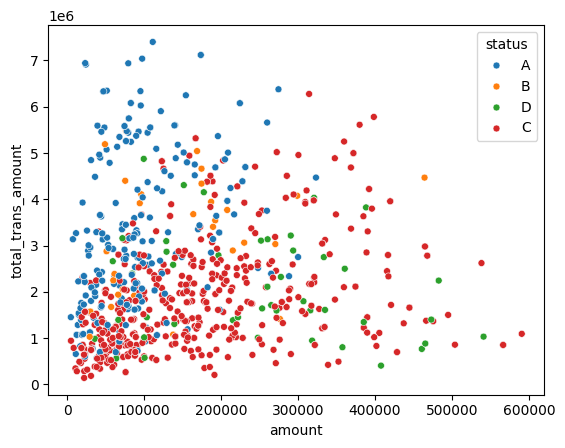

In [68]:
sns.scatterplot(data=main_df,x="amount",y="total_trans_amount",s=25,hue="status")

In [69]:
main_df['status'].value_counts()

status
C    493
A    258
D     45
B     31
Name: count, dtype: int64

In [70]:
main_df['status'] = main_df['status'].map({"A": 1, "B": 0, "C": 2, "D": 3})

In [71]:
main_df['status']

0      1
1      1
2      0
3      1
4      3
      ..
822    2
823    2
824    2
825    1
826    1
Name: status, Length: 827, dtype: int64

In [72]:
copy_df = main_df[["amount","total_trans_amount","status"]].copy()

In [73]:
copy_df

,amount,total_trans_amount,status
0,80952,3151479.3,1
1,80952,3151479.3,1
2,30276,1575515.9,0
3,30276,2958545.1,1
4,318480,948153.9,3
...,...,...,...
822,280440,1326820.0,2
823,419880,3957372.2,2
824,419880,3957372.2,2
825,54024,2948081.4,1


In [74]:
from sklearn.cluster import KMeans

In [75]:
cluster_k = []
for i in range(1,10):
    kmeans = KMeans(n_clusters=i,random_state=46)
    kmeans.fit(copy_df)
    cluster_k.append(kmeans.inertia_)
# inertia bir ozellik her noktanin,ait oldugu kumenin merkezine olan uzakliklarinin karelerinin toplami olarak tanimlanabilir. Kume sayisi arttikca inertia degerinin azalmasi beklenir. Ancak, belirli bir noktadan sonra inertia degeri cok az azalir ve bu noktada optimal kume sayisi olarak kabul edilir. Bu noktayi bulmak icin, cluster_k degerlerini kullanarak bir grafik cizilebilir ve "dirsek noktasi" olarak adlandirilan noktayi belirlemek icin incelenebilir.

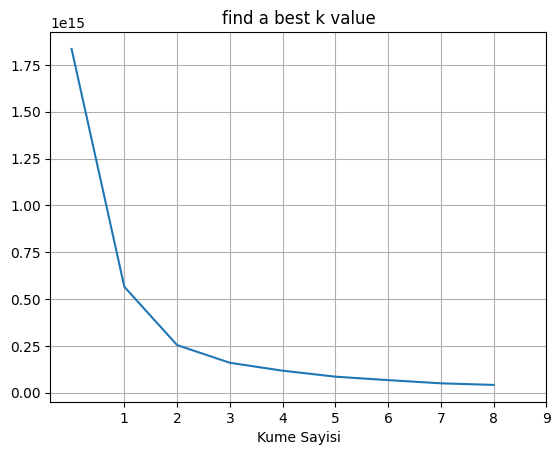

In [76]:
sns.lineplot(data=cluster_k)
plt.xticks(range(1,10))
plt.xlabel("Kume Sayisi")
plt.title("find a best k value")
plt.grid()

In [77]:
#k=4

In [78]:
cluster_model = KMeans(n_clusters=4)
cluster_model.fit(copy_df)
copy_df["cluster"] = cluster_model.predict(copy_df)

<Axes: xlabel='amount', ylabel='total_trans_amount'>

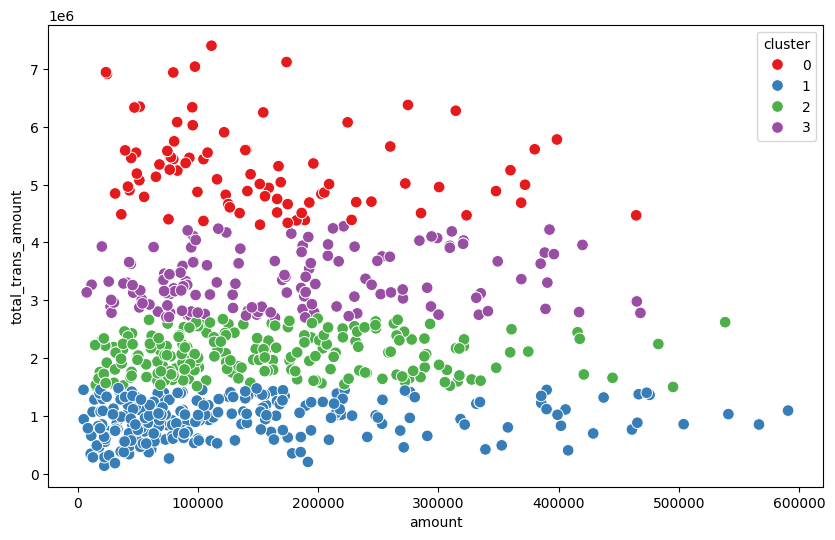

In [79]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=copy_df,x="amount",y="total_trans_amount",hue="cluster",s=70,palette="Set1")

In [80]:
main_df

,loan_id,account_id,amount,duration,payments,status,frequency,disp_id,client_id,birth_number,district_id,total_trans,total_trans_amount
0,4959,2,80952,24,3373.0,1,POPLATEK MESICNE,2,2,450204,1,478,3151479.3
1,4959,2,80952,24,3373.0,1,POPLATEK MESICNE,3,3,406009,1,478,3151479.3
2,4961,19,30276,12,2523.0,0,POPLATEK MESICNE,25,25,395423,21,303,1575515.9
3,4962,25,30276,12,2523.0,1,POPLATEK MESICNE,31,31,620209,68,274,2958545.1
4,4967,37,318480,60,5308.0,3,POPLATEK MESICNE,45,45,520826,20,130,948153.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...
822,7295,11328,280440,60,4674.0,2,POPLATEK MESICNE,13616,13924,525909,54,146,1326820.0
823,7304,11349,419880,60,6998.0,2,POPLATEK TYDNE,13647,13955,456030,1,304,3957372.2
824,7304,11349,419880,60,6998.0,2,POPLATEK TYDNE,13648,13956,430406,1,304,3957372.2
825,7305,11359,54024,12,4502.0,1,POPLATEK MESICNE,13660,13968,680413,61,378,2948081.4


In [81]:
main_df['frequency'].value_counts()

frequency
POPLATEK MESICNE      680
POPLATEK TYDNE        107
POPLATEK PO OBRATU     40
Name: count, dtype: int64

In [82]:
main_df.isna().sum()

loan_id               0
account_id            0
amount                0
duration              0
payments              0
status                0
frequency             0
disp_id               0
client_id             0
birth_number          0
district_id           0
total_trans           0
total_trans_amount    0
dtype: int64

In [83]:
main_df.describe()

,loan_id,account_id,amount,duration,payments,status,disp_id,client_id,birth_number,district_id,total_trans,total_trans_amount
count,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,8.270000e+02
mean,6180.746070,5863.874244,151801.538089,36.261185,4231.251511,1.667473,7049.634825,7171.419589,582148.870617,38.215236,282.499395,2.327635e+06
std,681.292733,3277.925506,114577.041848,17.172800,2238.757849,0.637370,3925.311133,4053.288033,129709.966792,25.033481,136.893018,1.486102e+06
min,4959.000000,2.000000,4980.000000,12.000000,304.000000,0.000000,2.000000,2.000000,341130.000000,1.000000,49.000000,1.418696e+05
25%,5585.000000,2988.000000,67536.000000,24.000000,2495.500000,1.000000,3608.500000,3608.500000,470126.500000,14.000000,175.000000,1.135261e+06
50%,6190.000000,5794.000000,115992.000000,36.000000,3937.000000,2.000000,7011.000000,7011.000000,580821.000000,41.000000,253.000000,2.020074e+06
75%,6760.500000,8757.000000,210564.000000,48.000000,5916.000000,2.000000,10487.500000,10795.500000,688169.500000,60.000000,392.500000,3.137644e+06
max,7308.000000,11362.000000,590820.000000,60.000000,9910.000000,3.000000,13663.000000,13971.000000,851019.000000,77.000000,675.000000,7.399358e+06


In [84]:
main_df['frequency']=main_df['frequency'].map({"POPLATEK MESICNE":1, "POPLATEK TYDNE":2, "POPLATEK PO OBRATU":3,})

In [85]:
copy_df = main_df.copy()
unscaled_cluster = KMeans(n_clusters=4,random_state=46)
unscaled_cluster.fit(copy_df)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",46
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [86]:
copy_df['cluster'] = unscaled_cluster.predict(copy_df)

In [87]:
copy_df.head()

,loan_id,account_id,amount,duration,payments,status,frequency,disp_id,client_id,birth_number,district_id,total_trans,total_trans_amount,cluster
0,4959,2,80952,24,3373.0,1,1,2,2,450204,1,478,3151479.3,1
1,4959,2,80952,24,3373.0,1,1,3,3,406009,1,478,3151479.3,1
2,4961,19,30276,12,2523.0,0,1,25,25,395423,21,303,1575515.9,0
3,4962,25,30276,12,2523.0,1,1,31,31,620209,68,274,2958545.1,1
4,4967,37,318480,60,5308.0,3,1,45,45,520826,20,130,948153.9,0


In [88]:
copy_df['cluster'].value_counts()

cluster
0    316
2    276
1    147
3     88
Name: count, dtype: int64

In [89]:
copy_df.head()

,loan_id,account_id,amount,duration,payments,status,frequency,disp_id,client_id,birth_number,district_id,total_trans,total_trans_amount,cluster
0,4959,2,80952,24,3373.0,1,1,2,2,450204,1,478,3151479.3,1
1,4959,2,80952,24,3373.0,1,1,3,3,406009,1,478,3151479.3,1
2,4961,19,30276,12,2523.0,0,1,25,25,395423,21,303,1575515.9,0
3,4962,25,30276,12,2523.0,1,1,31,31,620209,68,274,2958545.1,1
4,4967,37,318480,60,5308.0,3,1,45,45,520826,20,130,948153.9,0


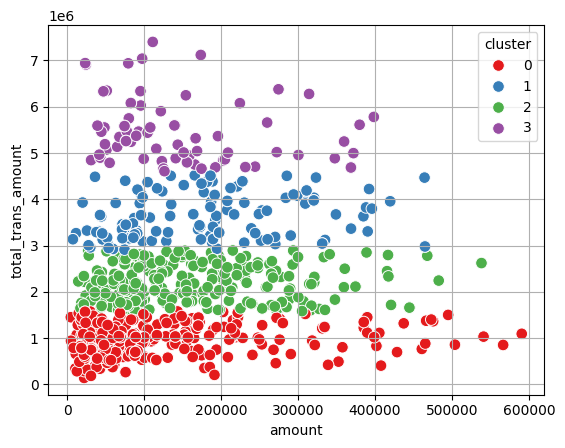

In [90]:
sns.scatterplot(data=copy_df,x="amount",y="total_trans_amount",hue="cluster",s=70,palette="Set1")
plt.grid()

In [91]:
## rescale
#describe big std = outlier check
# describe = big max = log

In [92]:
copy_df.describe()

,loan_id,account_id,amount,duration,payments,status,frequency,disp_id,client_id,birth_number,district_id,total_trans,total_trans_amount,cluster
count,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,8.270000e+02,827.000000
mean,6180.746070,5863.874244,151801.538089,36.261185,4231.251511,1.667473,1.226119,7049.634825,7171.419589,582148.870617,38.215236,282.499395,2.327635e+06,1.164450
std,681.292733,3277.925506,114577.041848,17.172800,2238.757849,0.637370,0.521587,3925.311133,4053.288033,129709.966792,25.033481,136.893018,1.486102e+06,1.056305
min,4959.000000,2.000000,4980.000000,12.000000,304.000000,0.000000,1.000000,2.000000,2.000000,341130.000000,1.000000,49.000000,1.418696e+05,0.000000
25%,5585.000000,2988.000000,67536.000000,24.000000,2495.500000,1.000000,1.000000,3608.500000,3608.500000,470126.500000,14.000000,175.000000,1.135261e+06,0.000000
50%,6190.000000,5794.000000,115992.000000,36.000000,3937.000000,2.000000,1.000000,7011.000000,7011.000000,580821.000000,41.000000,253.000000,2.020074e+06,1.000000
75%,6760.500000,8757.000000,210564.000000,48.000000,5916.000000,2.000000,1.000000,10487.500000,10795.500000,688169.500000,60.000000,392.500000,3.137644e+06,2.000000
max,7308.000000,11362.000000,590820.000000,60.000000,9910.000000,3.000000,3.000000,13663.000000,13971.000000,851019.000000,77.000000,675.000000,7.399358e+06,3.000000


In [93]:
# mean and median
# min vs max
# std vs mean


In [94]:
## mean >. max = outlier
## amount duration paymnents disp client_id	 district_id total_trans_amount

In [95]:
copy_df[['amount','duration','payments','disp_id','client_id','district_id','total_trans_amount']]

,amount,duration,payments,disp_id,client_id,district_id,total_trans_amount
0,80952,24,3373.0,2,2,1,3151479.3
1,80952,24,3373.0,3,3,1,3151479.3
2,30276,12,2523.0,25,25,21,1575515.9
3,30276,12,2523.0,31,31,68,2958545.1
4,318480,60,5308.0,45,45,20,948153.9
...,...,...,...,...,...,...,...
822,280440,60,4674.0,13616,13924,54,1326820.0
823,419880,60,6998.0,13647,13955,1,3957372.2
824,419880,60,6998.0,13648,13956,1,3957372.2
825,54024,12,4502.0,13660,13968,61,2948081.4


In [96]:
copy_df["amount"] = np.log1p(copy_df["amount"])
copy_df["duration"] = np.log1p(copy_df["duration"])
copy_df["payments"] = np.log1p(copy_df["payments"])
copy_df["disp_id"] = np.log1p(copy_df["disp_id"])
copy_df["client_id"] = np.log1p(copy_df["client_id"])
copy_df["district_id"] = np.log1p(copy_df["district_id"])
copy_df["total_trans_amount"] = np.log1p(copy_df["total_trans_amount"])

In [97]:
copy_df.describe()

,loan_id,account_id,amount,duration,payments,status,frequency,disp_id,client_id,birth_number,district_id,total_trans,total_trans_amount,cluster
count,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000
mean,6180.746070,5863.874244,11.615338,3.484903,8.167761,1.667473,1.226119,8.560833,8.571776,582148.870617,3.235868,282.499395,14.443169,1.164450
std,681.292733,3277.925506,0.857255,0.549945,0.674331,0.637370,0.521587,1.027657,1.035552,129709.966792,1.175743,136.893018,0.693054,1.056305
min,4959.000000,2.000000,8.513386,2.564949,5.720312,0.000000,1.000000,1.098612,1.098612,341130.000000,0.693147,49.000000,11.862671,0.000000
25%,5585.000000,2988.000000,11.120430,3.218876,7.822643,1.000000,1.000000,8.191325,8.191325,470126.500000,2.708050,175.000000,13.942351,0.000000
50%,6190.000000,5794.000000,11.661285,3.610918,8.278428,2.000000,1.000000,8.855378,8.855378,580821.000000,3.737670,253.000000,14.518645,1.000000
75%,6760.500000,8757.000000,12.257549,3.891820,8.685585,2.000000,1.000000,9.258033,9.286976,688169.500000,4.110874,392.500000,14.958983,2.000000
max,7308.000000,11362.000000,13.289268,4.110874,9.201401,3.000000,3.000000,9.522520,9.544811,851019.000000,4.356709,675.000000,15.816904,3.000000


In [98]:
# log transformation is doing great job no more extreme outliers

In [99]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
copy_df1 = main_df.copy()
sc = StandardScaler()
scaled_df = sc.fit_transform(copy_df1)
scaled_df = pd.DataFrame(scaled_df, columns=copy_df1.columns)
scaled_df.head()

,loan_id,account_id,amount,duration,payments,status,frequency,disp_id,client_id,birth_number,district_id,total_trans,total_trans_amount
0,-1.794361,-1.789370,-0.618731,-0.714421,-0.383593,-1.047863,-0.433782,-1.796520,-1.769861,-1.017846,-1.487518,1.428991,0.554701
1,-1.794361,-1.789370,-0.618731,-0.714421,-0.383593,-1.047863,-0.433782,-1.796265,-1.769615,-1.358773,-1.487518,1.428991,0.554701
2,-1.791424,-1.784181,-1.061287,-1.413623,-0.763497,-2.617759,-0.433782,-1.790657,-1.764184,-1.440436,-0.688105,0.149847,-0.506408
3,-1.789955,-1.782349,-1.061287,-1.413623,-0.763497,-1.047863,-0.433782,-1.789128,-1.762702,0.293602,1.190517,-0.062125,0.424797
4,-1.782612,-1.778686,1.455609,1.383186,0.481249,2.091929,-0.433782,-1.785559,-1.759246,-0.473055,-0.728075,-1.114678,-0.928817


In [100]:
# After scaling the data , we rechecked the number of clusters
cluster_k = []
for i in range(1,10):
    km = KMeans(n_clusters=i,random_state=46)
    km.fit(scaled_df)
    cluster_k.append(km.inertia_)

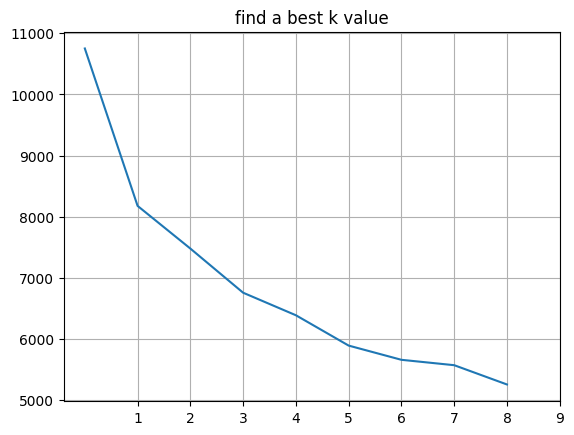

In [101]:
sns.lineplot(data=cluster_k)
plt.xticks(range(1,10))
plt.title("find a best k value")
plt.grid()

In [102]:
# k=5
scaled_cluster_model = KMeans(n_clusters=5,random_state=46)
scaled_cluster_model.fit(scaled_df)
scaled_df['cluster'] = scaled_cluster_model.predict(scaled_df)
scaled_df.head()

,loan_id,account_id,amount,duration,payments,status,frequency,disp_id,client_id,birth_number,district_id,total_trans,total_trans_amount,cluster
0,-1.794361,-1.789370,-0.618731,-0.714421,-0.383593,-1.047863,-0.433782,-1.796520,-1.769861,-1.017846,-1.487518,1.428991,0.554701,1
1,-1.794361,-1.789370,-0.618731,-0.714421,-0.383593,-1.047863,-0.433782,-1.796265,-1.769615,-1.358773,-1.487518,1.428991,0.554701,1
2,-1.791424,-1.784181,-1.061287,-1.413623,-0.763497,-2.617759,-0.433782,-1.790657,-1.764184,-1.440436,-0.688105,0.149847,-0.506408,1
3,-1.789955,-1.782349,-1.061287,-1.413623,-0.763497,-1.047863,-0.433782,-1.789128,-1.762702,0.293602,1.190517,-0.062125,0.424797,1
4,-1.782612,-1.778686,1.455609,1.383186,0.481249,2.091929,-0.433782,-1.785559,-1.759246,-0.473055,-0.728075,-1.114678,-0.928817,1


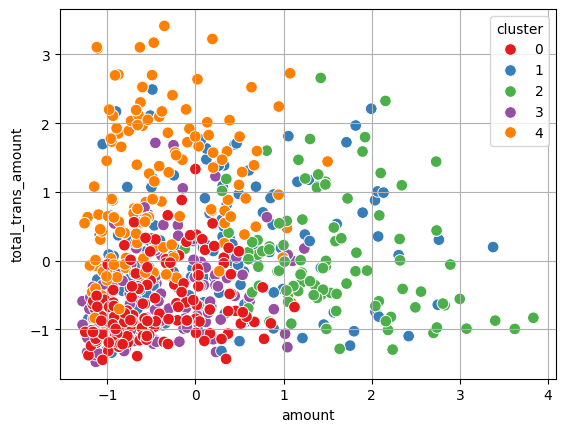

In [103]:
sns.scatterplot(data=scaled_df,x="amount",y="total_trans_amount",hue="cluster",s=70,palette="Set1")
plt.grid()

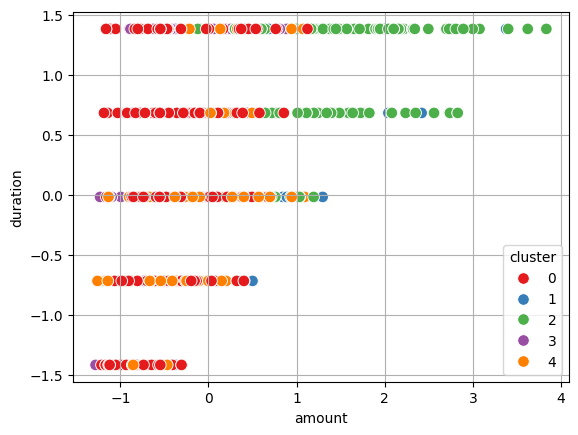

In [104]:
sns.scatterplot(data=scaled_df,x="amount",y="duration",hue="cluster",s=70,palette="Set1")
plt.grid()

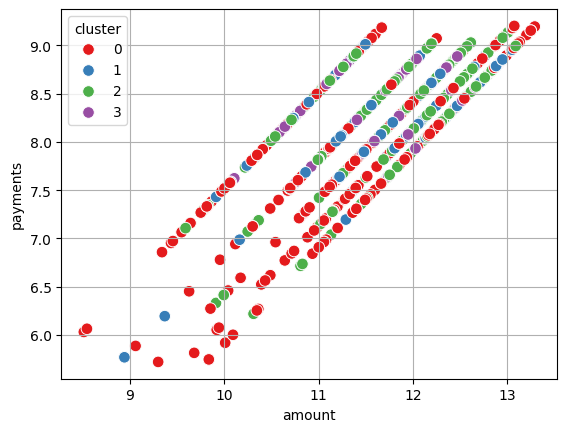

In [105]:
sns.scatterplot(data=copy_df,x="amount",y="payments",hue="cluster",s=70,palette="Set1")
plt.grid()

<Axes: xlabel='frequency', ylabel='payments'>

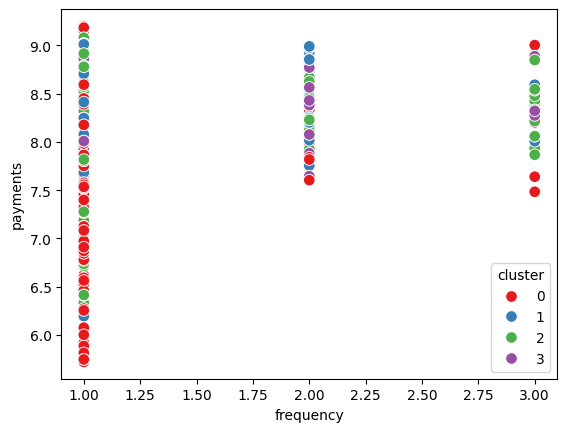

In [106]:
sns.scatterplot(data=copy_df,x="frequency",y="payments",hue="cluster",s=70,palette="Set1")

<Axes: xlabel='cluster', ylabel='amount'>

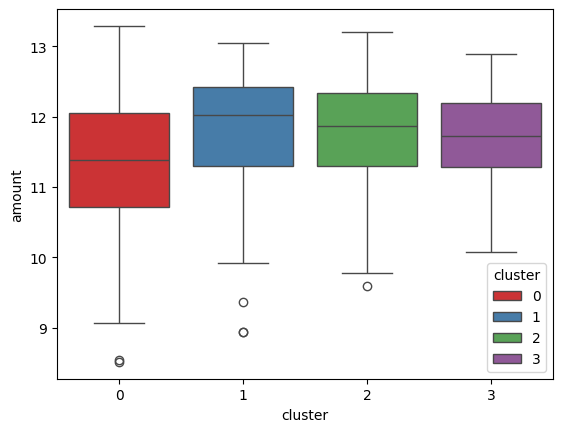

In [107]:
sns.boxplot(data=copy_df,x="cluster",y="amount",hue="cluster",palette="Set1")

In [108]:
scaled_df.groupby("cluster").mean()

,loan_id,account_id,amount,duration,payments,status,frequency,disp_id,client_id,birth_number,district_id,total_trans,total_trans_amount
cluster,,,,,,,,,,,,,
0,0.994400,0.998072,-0.451730,-0.023119,-0.465058,0.309166,-0.303722,0.996728,1.000917,0.001322,-0.056026,-0.484542,-0.620776
1,-1.224262,-1.216710,0.191016,-0.190974,0.483848,-0.164260,0.331475,-1.218495,-1.210086,-0.451643,0.029839,-0.038080,0.112503
2,0.473173,0.468798,1.642973,1.049054,0.935960,0.744319,0.075523,0.469802,0.465949,0.257353,0.033136,-0.137548,0.067037
3,-0.608353,-0.613212,-0.408234,0.133792,-0.638740,0.453404,-0.213640,-0.610449,-0.621240,0.202743,0.002755,-0.494578,-0.551506
4,0.619248,0.615455,-0.385667,-0.608109,0.028639,-1.121308,0.138368,0.615137,0.615895,0.094935,0.001214,1.162476,1.068069


In [109]:
#i build a supervised regression algorithm  for median house value

In [110]:
from sklearn.model_selection import train_test_split

In [111]:
train_df,test_df = train_test_split(main_df,random_state=46)

In [112]:
train_df.head()

,loan_id,account_id,amount,duration,payments,status,frequency,disp_id,client_id,birth_number,district_id,total_trans,total_trans_amount
188,5525,2720,93888,36,2608.0,2,2,3285,3285,435917,2,167,2073922.5
771,7168,10645,208332,36,5787.0,2,1,12782,13090,805418,2,163,2531327.1
578,6682,8225,36204,12,3017.0,3,1,9851,10159,380106,50,196,987028.5
132,5368,2073,44640,24,1860.0,2,1,2514,2514,570211,59,83,576532.9
438,6278,6265,87360,24,3640.0,2,1,7567,7567,370315,5,198,2235757.0


In [113]:
train_df.describe()

,loan_id,account_id,amount,duration,payments,status,frequency,disp_id,client_id,birth_number,district_id,total_trans,total_trans_amount
count,620.000000,620.000000,620.000000,620.000000,620.000000,620.000000,620.000000,620.000000,620.000000,620.000000,620.000000,620.000000,6.200000e+02
mean,6182.629032,5873.314516,148215.832258,36.251613,4162.537097,1.675806,1.233871,7060.666129,7183.369355,579975.985484,38.317742,278.145161,2.303258e+06
std,675.338241,3249.193955,110938.883329,17.125629,2194.325932,0.640372,0.528797,3890.289678,4018.468535,132064.328191,25.025945,135.860561,1.482640e+06
min,4959.000000,2.000000,7656.000000,12.000000,304.000000,0.000000,1.000000,2.000000,2.000000,341130.000000,1.000000,49.000000,1.418696e+05
25%,5588.250000,3002.250000,67887.000000,24.000000,2480.750000,1.000000,1.000000,3625.750000,3625.750000,460553.250000,14.750000,173.000000,1.106022e+06
50%,6196.000000,5842.500000,110124.000000,36.000000,3874.000000,2.000000,1.000000,7069.000000,7069.000000,580713.000000,41.000000,249.000000,1.978975e+06
75%,6758.000000,8742.000000,204150.000000,48.000000,5667.750000,2.000000,1.000000,10469.250000,10777.250000,692006.250000,60.250000,386.250000,3.133090e+06
max,7308.000000,11362.000000,590820.000000,60.000000,9910.000000,3.000000,3.000000,13663.000000,13971.000000,845918.000000,77.000000,675.000000,7.399358e+06


In [114]:
# max / median  amount  payments, frequency,birth_number
# std / mean   account_id,amount,payment,status,disp_id,client_id,district  
# a log transformation is appropriate.

In [115]:
train_df["loan_intensity"] =train_df["amount"] / train_df["total_trans_amount"]
train_df["amount_per_duration"] = train_df["amount"] / train_df["duration"]
test_df["loan_intensity"] =test_df["amount"] / test_df["total_trans_amount"]
test_df["amount_per_duration"] = test_df["amount"] / test_df["duration"]

In [116]:
train_df['loan_intensity']= np.log1p(train_df['loan_intensity'])
train_df['amount_per_duration']= np.log1p(train_df['amount_per_duration'])
train_df['account_id']= np.log1p(train_df['account_id'])
train_df['amount']= np.log1p(train_df['amount'])
train_df['payments']= np.log1p(train_df['payments'])
train_df['disp_id']= np.log1p(train_df['disp_id'])
train_df['client_id']= np.log1p(train_df['client_id'])
train_df['district_id']= np.log1p(train_df['district_id'])


In [117]:
test_df['loan_intensity']= np.log1p(test_df['loan_intensity'])
test_df['amount_per_duration']= np.log1p(test_df['amount_per_duration'])
test_df['account_id']= np.log1p(test_df['account_id'])
test_df['amount']= np.log1p(test_df['amount'])
test_df['payments']= np.log1p(test_df['payments'])
test_df['disp_id']= np.log1p(test_df['disp_id'])
test_df['client_id']= np.log1p(test_df['client_id'])
test_df['district_id']= np.log1p(test_df['district_id'])

In [118]:
x_train = train_df.drop(columns=['status'])
y_train = train_df['status']
x_test = test_df.drop(columns = ['status'])
y_test = test_df['status'] 


In [119]:
ss = StandardScaler()

#scale the data based on training set, then fit the test set to that same training scale
x_train_ss = ss.fit_transform(x_train)
x_train_ss = pd.DataFrame(x_train_ss, columns = x_train.columns)

x_test_ss = ss.transform(x_test)
x_test_ss = pd.DataFrame(x_test_ss, columns = x_test.columns)

#fit a cluster model to the training set
cluster_model = KMeans(n_clusters=5)
cluster_model.fit(x_train_ss)

#predict clusters for both training and testing datasets
x_train_ss['cluster'] = cluster_model.predict(x_train_ss)
x_test_ss['cluster'] = cluster_model.predict(x_test_ss)

In [120]:
x_train_ss = pd.get_dummies(x_train_ss, columns=['cluster'], prefix='cluster')
x_test_ss = pd.get_dummies(x_test_ss, columns=['cluster'], prefix='cluster')

# Kolonları hizala (test'te bazı cluster olmayabilir)
x_test_ss = x_test_ss.reindex(columns=x_train_ss.columns)

In [123]:
print(x_train_ss.iloc[123].filter(like='cluster'))

cluster_0    False
cluster_1     True
cluster_2    False
cluster_3    False
cluster_4    False
Name: 123, dtype: object


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score,recall_score 

In [124]:
logreg_model = LogisticRegression(class_weight='balanced',max_iter=1000)
logreg_model.fit(x_train_ss,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [125]:
train_preds = logreg_model.predict(x_train_ss)
test_preds = logreg_model.predict(x_test_ss)

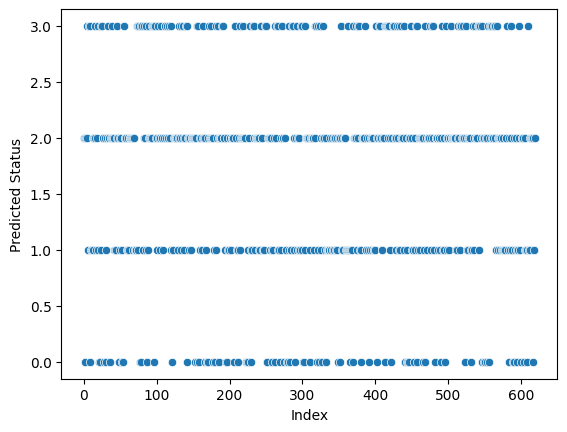

accuracy score: 0.646774193548387
recall score: 0.646774193548387
classification report:               precision    recall  f1-score   support

           0       0.15      0.57      0.24        23
           1       0.81      0.68      0.74       191
           2       0.94      0.64      0.76       370
           3       0.19      0.64      0.29        36

    accuracy                           0.65       620
   macro avg       0.52      0.63      0.51       620
weighted avg       0.83      0.65      0.71       620



In [128]:
from sklearn.metrics import accuracy_score, recall_score, classification_report

sns.scatterplot(x=range(len(train_preds)), y=train_preds)
plt.xlabel("Index")
plt.ylabel("Predicted Status")
plt.show()

print(f"accuracy score: {accuracy_score(y_train, train_preds)}")
print(f"recall score: {recall_score(y_train, train_preds, average='weighted')}")
print(f"classification report: {classification_report(y_train, train_preds)}")

In [130]:
from imblearn.over_sampling import SMOTE

In [132]:
smote = SMOTE(random_state=46)

In [133]:
x_train_ss,y_train = smote.fit_resample(x_train_ss,y_train)

In [134]:
logreg_model = LogisticRegression(class_weight='balanced',max_iter=1000)

In [135]:
logreg_model.fit(x_train_ss,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [138]:
train_preds = logreg_model.predict(x_train_ss)
test_preds = logreg_model.predict(x_test_ss)


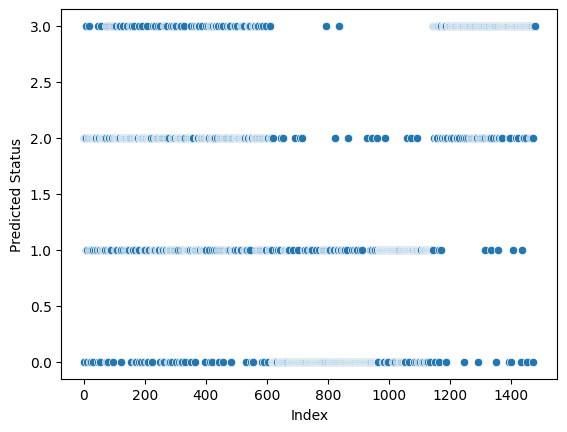

accuracy score: 0.7358108108108108
recall score: 0.7358108108108108
classification report:               precision    recall  f1-score   support

           0       0.76      0.77      0.76       370
           1       0.74      0.77      0.75       370
           2       0.69      0.72      0.70       370
           3       0.76      0.69      0.72       370

    accuracy                           0.74      1480
   macro avg       0.74      0.74      0.74      1480
weighted avg       0.74      0.74      0.74      1480



In [139]:

sns.scatterplot(x=range(len(train_preds)), y=train_preds)
plt.xlabel("Index")
plt.ylabel("Predicted Status")
plt.show()

print(f"accuracy score: {accuracy_score(y_train, train_preds)}")
print(f"recall score: {recall_score(y_train, train_preds, average='weighted')}")
print(f"classification report: {classification_report(y_train, train_preds)}")

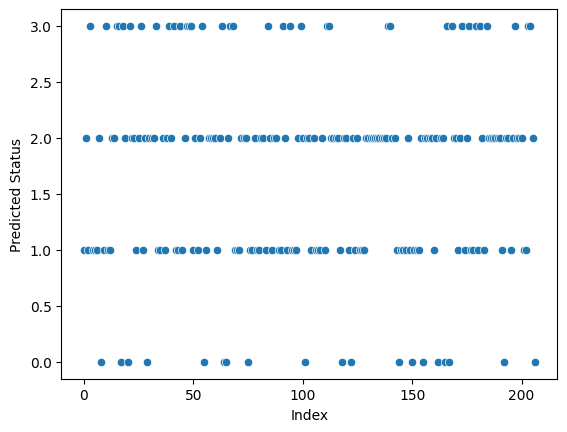

accuracy score: 0.6859903381642513
recall score: 0.6859903381642513
classification report:               precision    recall  f1-score   support

           0       0.16      0.38      0.22         8
           1       0.80      0.78      0.79        67
           2       0.94      0.67      0.78       123
           3       0.14      0.56      0.22         9

    accuracy                           0.69       207
   macro avg       0.51      0.59      0.50       207
weighted avg       0.83      0.69      0.74       207



In [140]:

sns.scatterplot(x=range(len(test_preds)), y=test_preds)
plt.xlabel("Index")
plt.ylabel("Predicted Status")
plt.show()

print(f"accuracy score: {accuracy_score(y_test, test_preds)}")
print(f"recall score: {recall_score(y_test, test_preds, average='weighted')}")
print(f"classification report: {classification_report(y_test, test_preds)}")

In [ ]:
## logistic regression model is doing better than the cluster model but still not good enough. I will try to do some feature engineering and then i will try to build a random forest model.

In [142]:
pd.DataFrame(logreg_model.coef_, columns=x_train_ss.columns)

,loan_id,account_id,amount,duration,payments,frequency,disp_id,client_id,birth_number,district_id,total_trans,total_trans_amount,loan_intensity,amount_per_duration,cluster_0,cluster_1,cluster_2,cluster_3,cluster_4
0,-0.866184,0.260026,-0.307155,-1.300921,0.679428,0.151819,0.343984,0.136512,-0.155828,-0.198354,2.045486,-0.254042,-0.705961,0.679428,1.335074,2.209682,0.815980,-0.446682,1.552157
1,0.461125,-0.146035,-0.467303,-2.032248,-0.121278,-0.117768,-0.214016,-0.154168,0.184544,-0.093935,2.177325,-0.044177,-0.165600,-0.121278,-0.991781,-2.088523,-0.250995,-0.195428,-0.934353
2,0.137979,-0.077922,-0.185039,1.915990,-0.437560,-0.025233,-0.039222,0.132118,-0.030552,-0.160668,-2.305876,-0.020824,0.464808,-0.437560,-1.585776,-2.842677,-1.597447,-1.694092,-1.189492
3,0.267080,-0.036070,0.959497,1.417179,-0.120590,-0.008819,-0.090747,-0.114461,0.001836,0.452957,-1.916935,0.319043,0.406753,-0.120590,1.242483,2.721518,1.032462,2.336202,0.571688


“Customers with high transaction activity are more likely to belong to this class, while longer loan duration decreases the likelihood.”